# **Insurance Customer Prediction**

In [ ]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    classification_report
)

In [ ]:
#Loading dataset

df = pd.read_csv('My Documents/BIA Capstone Project /Customer Responses to Insurance Policy/Data/data.csv')
display(df)

id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
6,Female,24,1,33.0,0,< 1 Year,Yes,2630.0,160.0,176,0
7,Male,23,1,11.0,0,< 1 Year,Yes,23367.0,152.0,249,0
8,Female,56,1,28.0,0,1-2 Year,Yes,32031.0,26.0,72,1
9,Female,24,1,3.0,1,< 1 Year,No,27619.0,152.0,28,0
10,Female,32,1,6.0,1,< 1 Year,No,28771.0,152.0,80,0


In [ ]:
#Rows & Columns of dataset

df.shape
print(f'Dataset Rows & Columns: ',df.shape)

Dataset Rows & Columns:  (381109, 12)


In [ ]:
#Information on dataset

df.info()
print(f'Dataset Information: ',df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 

In [ ]:
#Statistical description of dataset

df.describe(include='object')
print(f'Statistical Description: ',df.describe(include='object'))

Statistical Description:          Gender Vehicle_Age Vehicle_Damage
count   381109      381109         381109
unique       2           3              2
top       Male    1-2 Year            Yes
freq    206089      200316         192413


# **Data Exploration**

/home/spark-e668d222-239f-463a-9d3c-5d/.ipykernel/9557/command-7779973884429062-1085828604:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=response_counts.index, y=response_counts.values, palette='magma')


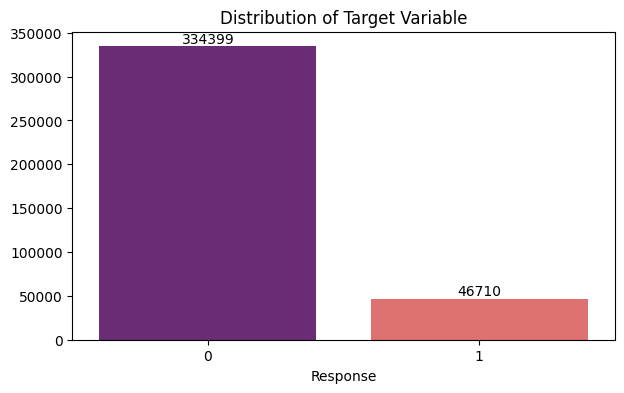

In [ ]:
#Analysing feature distribution w.r.t customer response

plt.rcParams['figure.figsize'] = (7, 4)
response_counts = df['Response'].value_counts()
ax = sns.barplot(x=response_counts.index, y=response_counts.values, palette='magma')
for i, count in enumerate(response_counts.values):
    ax.annotate(f'{count}', (i, count), ha='center', va='bottom')
plt.title('Distribution of Target Variable')
plt.show()

Text(0.5, 1.0, 'Distribution of Region')

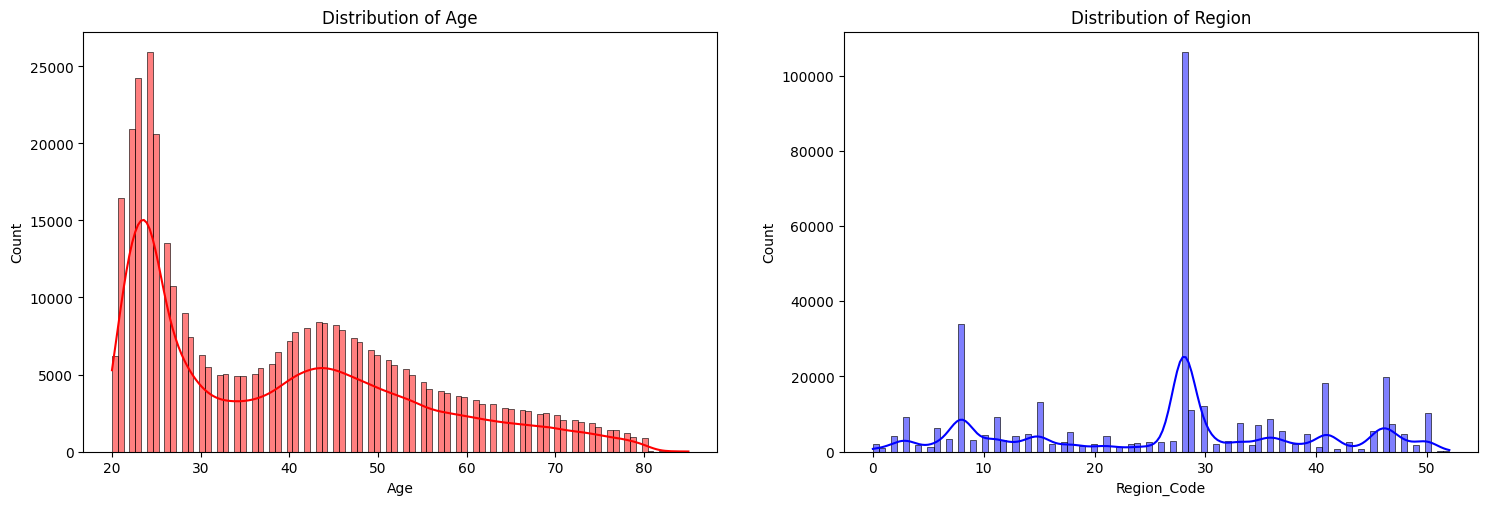

In [ ]:
#Distribution by age, region

plt.rcParams['figure.figsize'] = (18, 12)
plt.subplot(221)
sns.histplot(df['Age'], color='red', kde=True)
plt.title('Distribution of Age')

plt.subplot(222)
sns.histplot(df['Region_Code'], color='blue', kde=True)
plt.title('Distribution of Region')

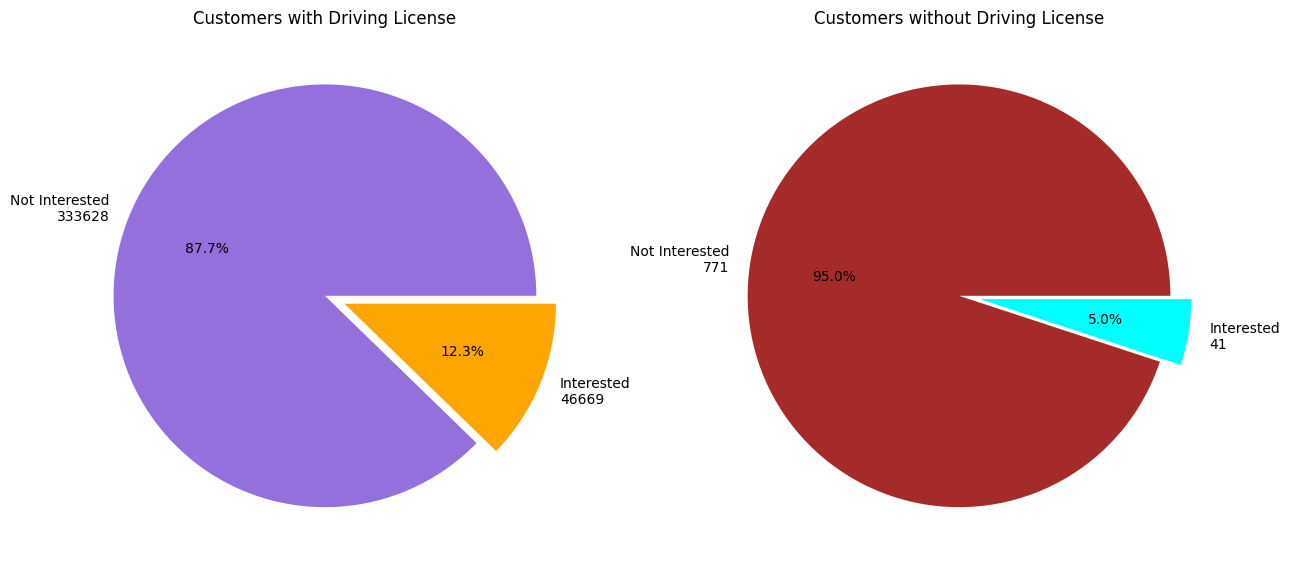

In [ ]:
#Customer's response basis driving license

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for i, license_status in enumerate([1, 0]):
    subset = df[df['Driving_License'] == license_status]
    counts = subset['Response'].value_counts().sort_index()
    labels = [
        f'Not Interested\n{counts.get(0, 0)}',
        f'Interested\n{counts.get(1, 0)}'
    ]
    colors = ['mediumpurple', 'orange'] if license_status == 1 else ['brown', 'cyan']
    axes[i].pie(counts, labels=labels, autopct='%1.1f%%', explode=[0, 0.1], colors=colors)
    title = 'Customers with Driving License' if license_status == 1 else 'Customers without Driving License'
    axes[i].set_title(title)
plt.show()

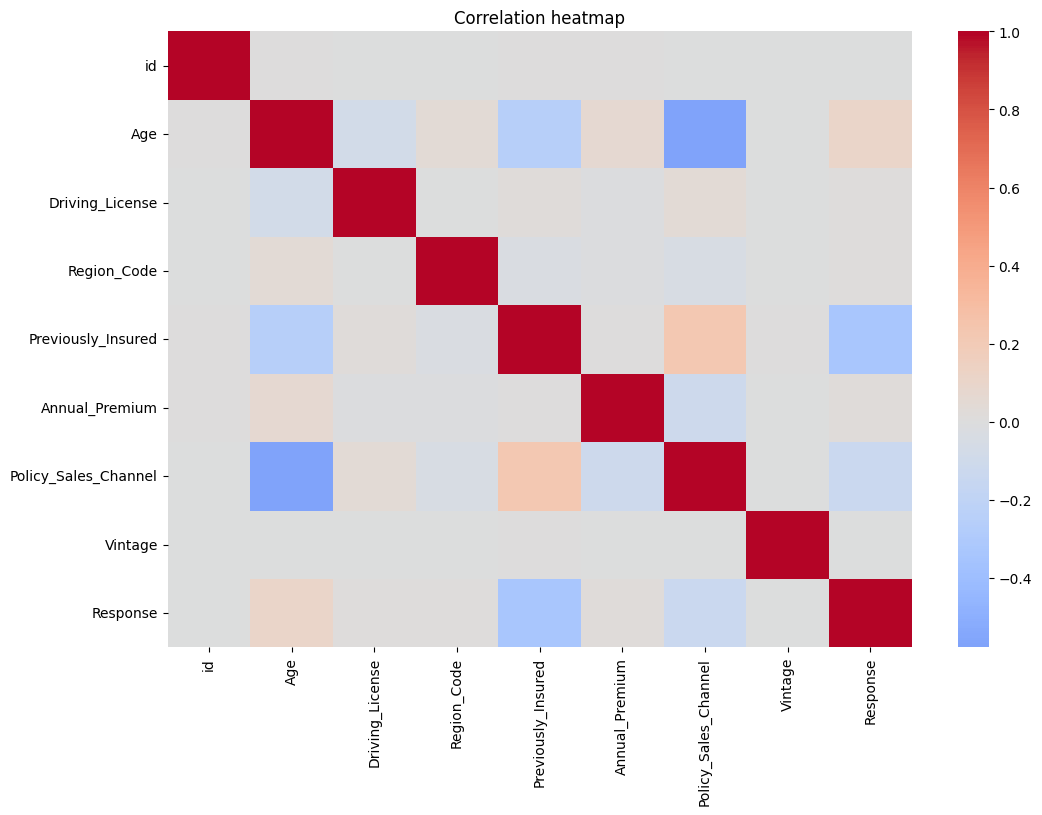

In [ ]:
#Correlation analysis

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_columns) > 1:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df[numeric_columns].corr(), annot=False, cmap='coolwarm', center=0)
    plt.title("Correlation heatmap")
    plt.show()
else:
    print("No numerical columns found.")

# **Data Preprocessing**

In [ ]:
#Identify count of missing values

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(f'Missing Values: ', missing_values)

#Separate numerical and categorical column

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns
print(f'Numerical Columns: ', numeric_columns)
print(f'Categorical Columns: ', categorical_columns)

#Handling missing value with median imputation

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

#Handling missing value with mode imputation

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

#Label encoding for categorical values

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

#View updated dataset
print(f'Label Encoded Dataset: ', df)
df.head()

#Feature Scaling numerical columns

scaler = StandardScaler()

for col in numeric_columns:
    df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

#View scaled dataset
print(f'Scaled Dataset: ', df)
df.head()

Missing Values:  Series([], dtype: int64)
Numerical Columns:  Index(['id', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')
Categorical Columns:  Index(['Gender', 'Vehicle_Age', 'Vehicle_Damage'], dtype='object')


/home/spark-e668d222-239f-463a-9d3c-5d/.ipykernel/9557/command-6002532323242423-2470239181:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/home/spark-e668d222-239f-463a-9d3c-5d/.ipykernel/9557/command-6002532323242423-2470239181:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

Label Encoded Dataset:              id  Gender  Age  ...  Policy_Sales_Channel  Vintage  Response
0            1       1   44  ...                  26.0      217         1
1            2       1   76  ...                  26.0      183         0
2            3       1   47  ...                  26.0       27         1
3            4       1   21  ...                 152.0      203         0
4            5       0   29  ...                 152.0       39         0
...        ...     ...  ...  ...                   ...      ...       ...
381104  381105       1   74  ...                  26.0       88         0
381105  381106       1   30  ...                 152.0      131         0
381106  381107       1   21  ...                 160.0      161         0
381107  381108       0   68  ...                 124.0       74         0
381108  381109       1   46  ...                  26.0      237         0

[381109 rows x 12 columns]
Scaled Dataset:                id  Gender       Age  ...  Po

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,-1.732046,1,0.333777,0.046208,0.121784,-0.919638,2,1,0.574539,-1.587234,0.748795,2.675639
1,-1.732037,1,2.396751,0.046208,-1.767879,-0.919638,0,0,0.172636,-1.587234,0.342443,-0.373742
2,-1.732028,1,0.527181,0.046208,0.121784,-0.919638,2,1,0.449053,-1.587234,-1.521998,2.675639
3,-1.732019,1,-1.148985,0.046208,-1.163187,1.087384,1,0,-0.113018,0.737321,0.581474,-0.373742
4,-1.732010,0,-0.633242,0.046208,1.104409,1.087384,1,0,-0.178259,0.737321,-1.378580,-0.373742


# **Feature Engineering**

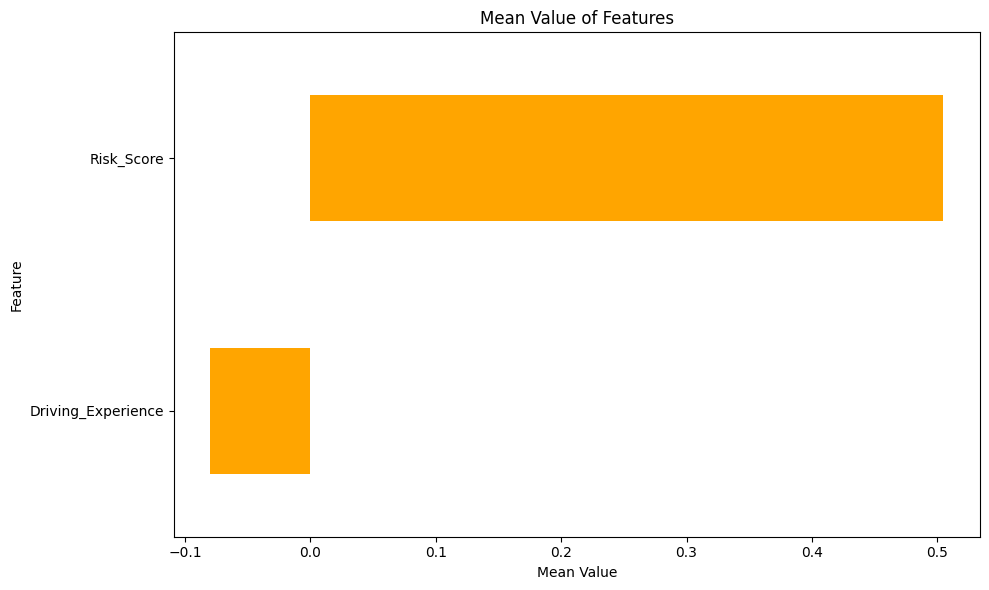

In [ ]:
#Create Age bucket feature 

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,30,50,100],
    labels=['Young','Middle','Senior']
)
df[['Age','Age_Group']].head()

#Combining age with driving license

df['Driving_Experience'] = df['Age'] * df['Driving_License']
df[['Age','Driving_License','Driving_Experience']].head()

#Create vehicle risk score

df['Risk_Score'] = (
    df['Vehicle_Damage'] + 
    df['Previously_Insured']
)
df[['Vehicle_Damage',
    'Previously_Insured',
    'Risk_Score']].head()

# Visualization for features

feature_cols = ['Age_Group', 'Driving_Experience', 'Risk_Score']
plt.figure(figsize=(10, 6))
means = df[feature_cols].mean(numeric_only=True)
means.plot(kind='barh', color='orange')
plt.title('Mean Value of Features')
plt.xlabel('Mean Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Split features and target

X = df.drop('Response', axis=1)
y = df['Response']

# Convert scaled Response back to integer classes

y = (y > y.median()).astype(int)

#Encode Age_Group

encoder = LabelEncoder()
df['Age_Group'] = encoder.fit_transform(df['Age_Group'])

# **Model Selection**

In [ ]:
#Encode Age Group for Modeling

if X['Age_Group'].dtype == 'object' or X['Age_Group'].dtype.name == 'category':
    encoder = LabelEncoder()
    X['Age_Group'] = encoder.fit_transform(X['Age_Group'].astype(str))

#Split train and test data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

#Create Logistic Regression Model

logistic_model = LogisticRegression(
    max_iter=1000
)
logistic_model.fit(
    X_train,
    y_train
)
logistic_prediction = logistic_model.predict(
    X_test
)
lr_probability = logistic_model.predict_proba(X_test)[:,1]

#Create Decision Tree Classifier Model

dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(
    X_train,
    y_train
)
dt_prediction = dt_model.predict(
    X_test
)
dt_probability = dt_model.predict_proba(X_test)[:,1]

#Create Random Forest Classifier Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(
    X_train,
    y_train
)
rf_prediction = rf_model.predict(
    X_test
)
rf_probability = rf_model.predict_proba(X_test)[:,1]

Training data: (304887, 14)
Testing data: (76222, 14)


# **Performance Evaluation**

/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Model Performance Comparison:


Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.8750623179659416,0.0,0.0,0.0,0.8235951720089074
Decision Tree,0.8202487470808952,0.29059743384121894,0.3044208757744408,0.297348581978563,0.5991586679956178
Random Forest,0.8691060323791031,0.38980582524271845,0.08432216738422765,0.13865147198480532,0.8402585530434414


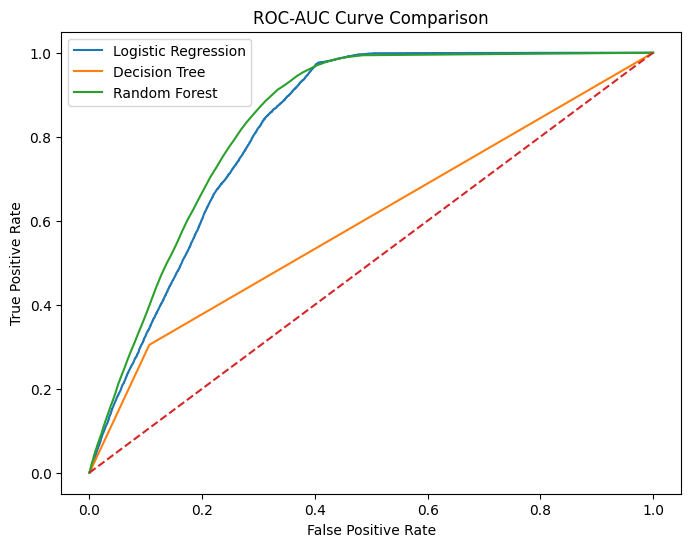

In [ ]:
def evaluate_model(model_name, y_test, prediction, probability):
    return {
        "Model": model_name,
        "Accuracy":
        accuracy_score(
            y_test,
            prediction
        ),
        "Precision":
        precision_score(
            y_test,
            prediction
        ),
        "Recall":
        recall_score(
            y_test,
            prediction
        ),
        "F1 Score":
        f1_score(
            y_test,
            prediction
        ),
        "ROC-AUC":
        roc_auc_score(
            y_test,
            probability
        )
    }

#Compare Model Performance

results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_prediction,
        lr_probability
    ),
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_prediction,
        dt_probability
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_prediction,  
        rf_probability
    )
])
print("\nModel Performance Comparison:")
display(results)

#ROC-AUC Curve evaluation

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_probability
)
dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_probability
)
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probability
)
plt.figure(figsize=(8,6))
plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)
plt.plot(
    dt_fpr,
    dt_tpr,
    label="Decision Tree"
)
plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)
# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)
plt.ylabel(
    "True Positive Rate"
)
plt.title(
    "ROC-AUC Curve Comparison"
)
plt.legend()
plt.show() 

--Model Training, Evaluation Successfully Completed--